#### This notebook looks at temperature-dependent changes to embryo morphology

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from glob2 import glob
from sklearn.cluster import KMeans

In [2]:
# load embryo_df for our current best model
# root = "/media/nick/hdd02/Cole Trapnell's Lab Dropbox/Nick Lammers/Nick/morphseq/"

root = "/Users/nick/Cole Trapnell's Lab Dropbox/Nick Lammers/Nick/morphseq/"

# path to save data
read_path = os.path.join(root, "results", "20250312", "morph_latent_space", "")

# path to figures and data
fig_path = "/Users/nick/Projects/data/morphseq/results/20260528/sac_figs/"
fig_data_path = os.path.join(fig_path, "data", "")
os.makedirs(fig_path, exist_ok=True)
os.makedirs(fig_data_path, exist_ok=True)

In [3]:
import joblib

# load datasets
hf_pca_df = pd.read_csv(os.path.join(read_path, "hf_pca_morph_df.csv"))
ref_pca_df = pd.read_csv(os.path.join(read_path, "ab_ref_pca_morph_df.csv"))
spline_df = pd.read_csv(os.path.join(read_path, "spline_morph_df_full.csv"))
spline_df["knot_index"] = spline_df.index

# Save the model to a file
# morph_stage_model = joblib.load(os.path.join(read_path, 'morph_stage_model.joblib'))

## Plot ref trajectories

In [4]:
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize, to_rgba
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

SAC_FIG_DIR = Path(fig_path)
SAC_FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": False,
})

COLLECTION_MARKERS = {24: "o", 30: "s", 36: "^"}
COLLECTION_LABELS = {24: "24 hpf", 30: "30 hpf", 36: "36 hpf"}

STAGE_CMAP = mpl.colormaps["viridis"]
PLASMA_CMAP = mpl.colormaps["plasma"]
SPLINE_CMAP = mpl.colormaps["YlOrRd_r"]

def make_temperature_cmap():
    base = mpl.colormaps["RdBu_r"](np.linspace(0, 1, 11))
    base[0] = to_rgba("#636EFA")
    base[(len(base) - 1) // 2] = to_rgba("#D3D3D3")
    return LinearSegmentedColormap.from_list("hotfish_temperature", base)

TEMP_CMAP = make_temperature_cmap()
TEMP_NORM = Normalize(19, 38)
STAGE_NORM = Normalize(10, 42)
SPLINE_NORM = Normalize(10, 46)

angle_vec = np.linspace(0, 360, 50)
t_lim_vec = np.linspace(12, 48, 50)
marker_size = 4

frame_path = os.path.join(fig_path, "ref_pca_rot_frames", "")
os.makedirs(frame_path, exist_ok=True)

# set plot parameters
zoom_factor = 0.21
z_rotation = -30 + 102
elevation = -10
marker_size = 3

xrange = [-2.2, 2.5]
yrange = [-2.7, 1.6]
zrange = [-2.1, 1.7]

pca_axis_labels=["morph PC 1", "morph PC 2", "morph PC 3"]


def save_matplotlib_figure(fig, output_stem, *, png_only=False):
    suffixes = ("png",) if png_only else ("png", "pdf")
    for suffix in suffixes:
        output_path = SAC_FIG_DIR / f"{output_stem}.{suffix}"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.18,
            facecolor=fig.get_facecolor(),
        )


def marker_for_collection(value):
    if pd.isna(value):
        return "o"
    try:
        value = int(round(float(value)))
    except (TypeError, ValueError):
        return "o"
    return COLLECTION_MARKERS.get(value, "o")


def collection_values(data):
    if "timepoint" not in data.columns:
        return [None]
    return sorted(data["timepoint"].dropna().unique())


def add_collection_legend(ax, *, loc="upper left", bbox_to_anchor=None, fontsize=10):
    handles = [
        Line2D(
            [0], [0], marker=marker, color="black", label=COLLECTION_LABELS[timepoint],
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.4,
            markersize=8, linestyle="None",
        )
        for timepoint, marker in COLLECTION_MARKERS.items()
    ]
    return ax.legend(handles=handles, title="collection", frameon=False, loc=loc,
                     bbox_to_anchor=bbox_to_anchor, fontsize=fontsize, title_fontsize=fontsize)


def create_3d_figure(figsize=(6.7, 5.6)):
    fig = plt.figure(figsize=figsize, facecolor="white")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("white")
    return fig, ax


def add_3d_axis_arrows(ax, xr, yr, zr, *, color="black", linewidth=2.1):
    x0, x1 = xr
    y0, y1 = yr
    z0, z1 = zr
    ax.quiver(x0, y0, z0, x1 - x0, 0, 0, color=color, linewidth=linewidth,
              arrow_length_ratio=0.055, normalize=False)
    ax.quiver(x0, y0, z0, 0, y1 - y0, 0, color=color, linewidth=linewidth,
              arrow_length_ratio=0.055, normalize=False)
    ax.quiver(x0, y0, z0, 0, 0, z1 - z0, color=color, linewidth=linewidth,
              arrow_length_ratio=0.055, normalize=False)


def style_3d_axes(ax, *, axis_labels, ranges, elev, azim, ticks=(-2, -1, 0, 1, 2)):
    xr, yr, zr = ranges
    ax.set_xlim(xr)
    ax.set_ylim(yr)
    ax.set_zlim(zr)
    ax.set_xlabel(axis_labels[0], labelpad=10, color="black")
    ax.set_ylabel(axis_labels[1], labelpad=10, color="black")
    ax.set_zlabel("")
    ax.text2D(-0.06, 0.50, axis_labels[2], transform=ax.transAxes,
              rotation=90, va="center", ha="center", color="black")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.tick_params(colors="black", width=1.6, length=4, pad=2)
    ax.grid(False)
    ax.set_box_aspect((xr[1] - xr[0], yr[1] - yr[0], zr[1] - zr[0]))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((1, 1, 1, 0))
        axis._axinfo["grid"]["linewidth"] = 0
        axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        axis.line.set_color("black")
        axis.line.set_linewidth(2.0)
    add_3d_axis_arrows(ax, xr, yr, zr)
    ax.set_xlim(xr)
    ax.set_ylim(yr)
    ax.set_zlim(zr)
    ax.view_init(elev=elev, azim=azim)


def point_area(marker_size):
    return (marker_size * 2.0) ** 2


def scatter3d_by_collection(
    ax,
    data,
    *,
    x,
    y,
    z,
    c=None,
    cmap=None,
    norm=None,
    marker_size=3,
    alpha=1,
    edgecolor="black",
    linewidth=0.4,
    zorder=2,
):
    scatter = None
    for timepoint in collection_values(data):
        if timepoint is None:
            plot_data = data
        else:
            plot_data = data.loc[np.isclose(data["timepoint"].astype(float), float(timepoint))]
        if plot_data.empty:
            continue
        colors = plot_data[c] if c is not None else None
        scatter = ax.scatter(
            plot_data[x], plot_data[y], plot_data[z],
            c=colors, cmap=cmap, norm=norm,
            marker=marker_for_collection(timepoint),
            s=point_area(marker_size), alpha=alpha,
            edgecolors=edgecolor, linewidths=linewidth,
            depthshade=False, zorder=zorder,
        )
    return scatter


def add_3d_colorbar(fig, ax, *, cmap, norm, label):
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, shrink=0.62)
    cbar.set_label(label, color="black")
    cbar.outline.set_edgecolor("black")
    cbar.ax.tick_params(colors="black", width=1.4)
    return cbar


def add_gradient_line3d(ax, x, y, z, c, *, cmap, norm, linewidth=3.0, alpha=1.0):
    points = np.column_stack([x, y, z])
    if len(points) < 2:
        return None
    segments = np.stack([points[:-1], points[1:]], axis=1)
    color_values = 0.5 * (np.asarray(c[:-1]) + np.asarray(c[1:]))
    collection = Line3DCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth, alpha=alpha)
    collection.set_array(color_values)
    ax.add_collection3d(collection)
    return collection


def set_axis_arrows_2d(ax, *, linewidth=2.2):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", colors="black", width=1.8, length=7, direction="out")
    ax.annotate("", xy=(1.03, 0), xytext=(0, 0), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=linewidth, mutation_scale=18),
                clip_on=False)
    ax.annotate("", xy=(0, 1.03), xytext=(0, 0), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=linewidth, mutation_scale=18),
                clip_on=False)


100%|██████████| 50/50 [00:14<00:00,  3.36it/s]


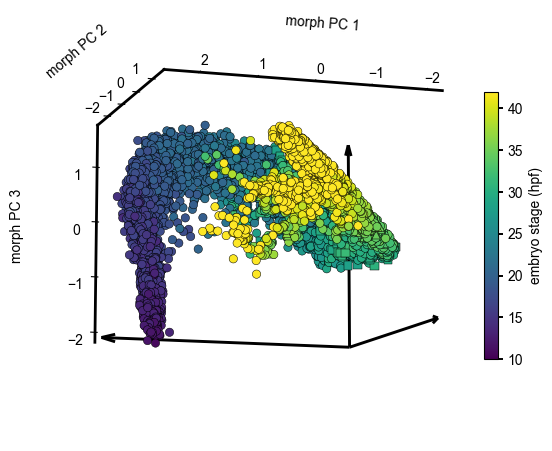

In [5]:
last_fig = None
for t, t_lim in enumerate(tqdm(t_lim_vec)):
    angle = angle_vec[t]
    t_filter = ref_pca_df["mdl_stage_hpf"] <= t_lim

    fig, ax = create_3d_figure()
    scatter3d_by_collection(
        ax,
        ref_pca_df.loc[t_filter],
        x="PCA_00_bio", y="PCA_01_bio", z="PCA_02_bio",
        c="mdl_stage_hpf", cmap=STAGE_CMAP, norm=STAGE_NORM,
        marker_size=marker_size, alpha=1, edgecolor="black", linewidth=0.35,
    )
    style_3d_axes(
        ax,
        axis_labels=pca_axis_labels,
        ranges=(xrange, yrange, zrange),
        elev=elevation,
        azim=z_rotation + angle,
    )
    add_3d_colorbar(fig, ax, cmap=STAGE_CMAP, norm=STAGE_NORM, label="embryo stage (hpf)")
    save_matplotlib_figure(fig, f"ref_pca_rot_frames/ref_pca_ab_angle{t:02}", png_only=True)
    if last_fig is not None:
        plt.close(last_fig)
    last_fig = fig

plt.show()

In [6]:
# Optional 2D reference PCA projection removed from this presentation notebook.
# The active reference trajectory rendering above is now Matplotlib-based.

### Now add lines for individual embryo

In [7]:
start_stage = 12
stop_stage = 38
# get list of embryo IDs
embryo_df = ref_pca_df.loc[:, [ "embryo_id", "mdl_stage_hpf"]].groupby(
                        [ "embryo_id"])["mdl_stage_hpf"].agg(["min", "max"]).reset_index()

stage_filter = (embryo_df["min"] <= start_stage) & (embryo_df["max"] >= stop_stage)

# indices_to_plot = np.asarray([1, 4, 7])
# embryo_id_index = np.unique(ref_pca_df["embryo_id"])
embryo_ids_to_plot = embryo_df.loc[stage_filter, "embryo_id"].to_numpy()
n_plot = 3
# np.sum(stage_filter)

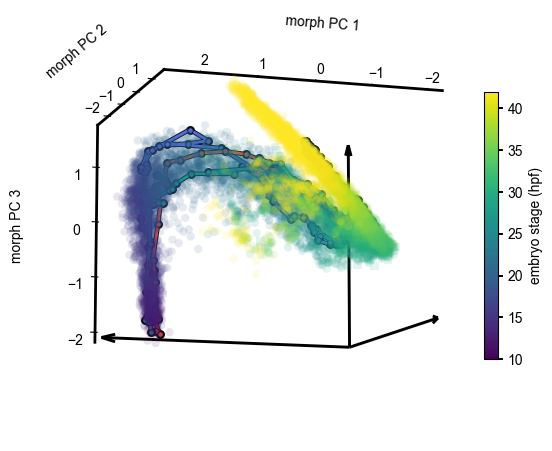

In [8]:
color_list = ["#636EFA", "#EF553B", "#00CC96"]

fig, ax = create_3d_figure()
scatter3d_by_collection(
    ax,
    ref_pca_df,
    x="PCA_00_bio", y="PCA_01_bio", z="PCA_02_bio",
    c="mdl_stage_hpf", cmap=STAGE_CMAP, norm=STAGE_NORM,
    marker_size=3, alpha=0.12, edgecolor="none", linewidth=0,
)
style_3d_axes(
    ax,
    axis_labels=pca_axis_labels,
    ranges=(xrange, yrange, zrange),
    elev=elevation,
    azim=z_rotation,
)
add_3d_colorbar(fig, ax, cmap=STAGE_CMAP, norm=STAGE_NORM, label="embryo stage (hpf)")
save_matplotlib_figure(fig, f"embryo_lines{0:02}")

for e, embryo_id in enumerate(embryo_ids_to_plot[:n_plot]):
    plot_filter = ref_pca_df["embryo_id"] == embryo_id
    embryo_plot = ref_pca_df.loc[plot_filter].sort_values("mdl_stage_hpf")

    ax.plot(
        embryo_plot["PCA_00_bio"], embryo_plot["PCA_01_bio"], embryo_plot["PCA_02_bio"],
        color="black", linewidth=3.4, marker="o", markersize=5.4,
    )
    ax.plot(
        embryo_plot["PCA_00_bio"], embryo_plot["PCA_01_bio"], embryo_plot["PCA_02_bio"],
        color=color_list[e], linewidth=2.0, marker="o", markersize=4.0,
        markeredgecolor="black", markeredgewidth=0.7,
    )
    save_matplotlib_figure(fig, f"embryo_lines{e+1:02}")

plt.show()

### Flux plot

In [9]:
from tqdm import tqdm

pca_cols = [col for col in ref_pca_df.columns if "PCA" in col]

# calculate per-point velocity for each embryo
embryo_index = np.unique(ref_pca_df["embryo_id"])

ref_pca_df.loc[:, "PCA_00_3_vel"] = np.nan
ref_pca_df.loc[:, "PCA_01_3_vel"] = np.nan
ref_pca_df.loc[:, "PCA_02_3_vel"] = np.nan

for e, embryo in enumerate(tqdm(embryo_index, "Extracting embryo velocities...")):
    s_indices = np.where(ref_pca_df["embryo_id"]==embryo)[0]
    
    u0 = ref_pca_df.loc[s_indices, pca_cols[0]].to_numpy()
    u1 = ref_pca_df.loc[s_indices, pca_cols[1]].to_numpy()
    u2 = ref_pca_df.loc[s_indices, pca_cols[2]].to_numpy()

    if len(u0) > 5:
    
        t = ref_pca_df.loc[s_indices, "mdl_stage_hpf"].to_numpy()
        
        du0 = np.divide(np.diff(u0), np.diff(t))
        du1 = np.divide(np.diff(u1), np.diff(t))
        du2 = np.divide(np.diff(u2), np.diff(t))
        
        ref_pca_df.loc[s_indices[:-1], "PCA_00_3_vel"] = du0
        ref_pca_df.loc[s_indices[:-1], "PCA_01_3_vel"] = du1
        ref_pca_df.loc[s_indices[:-1], "PCA_02_3_vel"] = du2
    
        ref_pca_df.loc[s_indices[-1], "PCA_00_3_vel"] = du0[-1]
        ref_pca_df.loc[s_indices[-1], "PCA_01_3_vel"] = du1[-1]
        ref_pca_df.loc[s_indices[-1], "PCA_02_3_vel"] = du2[-1]

Extracting embryo velocities...: 100%|██████████| 141/141 [00:00<00:00, 667.71it/s]


In [10]:
# use NN logic to calculate smooth flux field
from scipy.spatial import cKDTree

v_array_raw = ref_pca_df[["PCA_00_3_vel", "PCA_01_3_vel", "PCA_02_3_vel"]].to_numpy()
v_norm = np.sqrt(np.sum(v_array_raw**2, axis=1))
v_max = 5
norm_vec = np.ones_like(v_norm)
norm_vec[v_norm>v_max] = v_max * v_norm[v_norm>v_max]**-1
v_array_c = np.multiply(norm_vec[:, None], v_array_raw)


knn = 25

# get NN info
pts = ref_pca_df[pca_cols].to_numpy()
tree = cKDTree(pts)
distances, indices = tree.query(pts, k=knn+1)

# pull vel info
v0_vec = v_array_c[:, 0] #ref_pca_df.loc[:, "PCA_00_3_vel"].to_numpy()
v1_vec = v_array_c[:, 1] #ref_pca_df.loc[:, "PCA_01_3_vel"].to_numpy()
v2_vec = v_array_c[:, 2] #ref_pca_df.loc[:, "PCA_02_3_vel"].to_numpy()

v_array = np.hstack((np.mean(v0_vec[indices], axis=1)[:,None], 
                     np.mean(v1_vec[indices], axis=1)[:,None], 
                     np.mean(v2_vec[indices], axis=1)[:,None]))

p_array = np.hstack((np.mean(pts[indices, 0], axis=1)[:,None], 
                     np.mean(pts[indices, 1], axis=1)[:,None], 
                     np.mean(pts[indices, 2], axis=1)[:,None]))

flux_df = pd.DataFrame(pts[:, :3], columns=["pc0", "pc1", "pc2"])
flux_df["stage"] = ref_pca_df["mdl_stage_hpf"].to_numpy()
flux_df[["v0", "v1", "v2"]] = v_array

In [11]:
# from sklearn.cluster import KMeans

cluster_size = 10
max_pert_clusters = 1000
min_p = 5

# pull out raw PCA coordinates
pca_array = pts[:, :3] #ref_pca_df.loc[:, pca_cols[:3]].to_numpy()
pca_v_array = v_array
age_vec = ref_pca_df.loc[:, "mdl_stage_hpf"].to_numpy()
n_points = pca_array.shape[0]

n_clusters = np.min([int(np.round(n_points/cluster_size)), max_pert_clusters])

# cluster
kmeans_out = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(pca_array)
label_vec = kmeans_out.labels_

label_index, ia, label_counts = np.unique(label_vec, return_counts=True, return_inverse=True)

ref_pca_df.loc[:, "kmeans_label"] = label_vec
ref_pca_df.loc[:, "cluster_counts"] = label_counts[ia]

label_index = label_index[label_counts>4]
label_counts = label_counts[label_counts>4]

k_df = pd.DataFrame(label_index, columns=["kmeans_label"])
k_df["cluster_counts"] = label_counts
k_df["n_clusters"] = n_clusters
for l, lb in enumerate(label_index):
    
    k_df.loc[l, "X"] = np.mean(pca_array[label_vec==lb, 0])
    k_df.loc[l, "Y"] = np.mean(pca_array[label_vec==lb, 1])
    k_df.loc[l, "Z"] = np.mean(pca_array[label_vec==lb, 2])

    k_df.loc[l, "dX"] = np.mean(pca_v_array[label_vec==lb, 0])
    k_df.loc[l, "dY"] = np.mean(pca_v_array[label_vec==lb, 1])
    k_df.loc[l, "dZ"] = np.mean(pca_v_array[label_vec==lb, 2])

    k_df.loc[l, "stage_hpf"] = np.mean(age_vec[label_vec==lb])

# cluster_df_list.append(k_df)


cluster_df = k_df

100%|██████████| 50/50 [00:09<00:00,  5.31it/s]


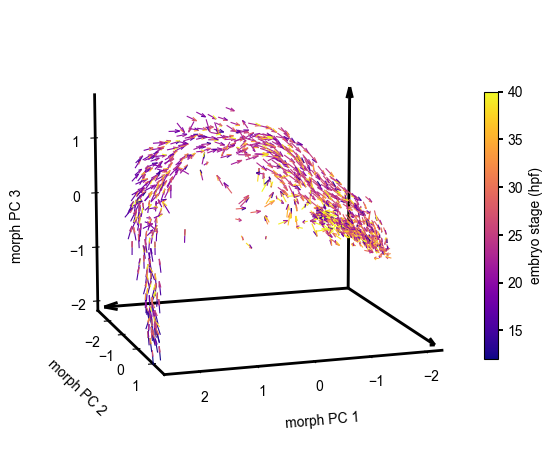

In [12]:
flux_path = os.path.join(fig_path, "flux_frames2")
os.makedirs(flux_path, exist_ok=True)

elevation_start = -10
elevation_end = 12
e_vec = np.linspace(elevation_start, elevation_end, 50)
t_lim_vec = np.linspace(12, 42, 50)

# set plot parameters
zoom_factor = 0.21
z_rotation = -30 + 102

marker_size = 3

xrange = [-2.2, 2.5]
yrange = [-2.7, 1.6]
zrange = [-2.1, 1.7]
cmin=12
cmax=40
flux_norm = Normalize(cmin, cmax)
pca_axis_labels=["morph PC 1", "morph PC 2", "morph PC 3"]

max_v = 0.3
offset = .1
last_fig = None

for ti, tlim in enumerate(tqdm(t_lim_vec)):
    plot_df = cluster_df.loc[cluster_df["stage_hpf"] <= tlim]
    X, Y, Z = plot_df['X'].to_numpy(), plot_df['Y'].to_numpy(), plot_df['Z'].to_numpy()
    dX, dY, dZ = plot_df['dX'].to_numpy(), plot_df['dY'].to_numpy(), plot_df['dZ'].to_numpy()
    C = np.clip(plot_df['stage_hpf'].to_numpy(), cmin, cmax)

    v = np.sqrt(dX**2 + dY**2 + dZ**2)
    valid = np.isfinite(v) & (v > 0)
    U = np.divide(dX, v, out=np.zeros_like(dX), where=valid)
    V = np.divide(dY, v, out=np.zeros_like(dY), where=valid)
    W = np.divide(dZ, v, out=np.zeros_like(dZ), where=valid)
    colors = PLASMA_CMAP(flux_norm(C))

    fig, ax = create_3d_figure()
    ax.quiver(
        X[valid], Y[valid], Z[valid], U[valid], V[valid], W[valid],
        length=0.24, normalize=False, colors=colors[valid], linewidth=0.8,
        arrow_length_ratio=0.45,
    )
    style_3d_axes(
        ax,
        axis_labels=pca_axis_labels,
        ranges=(xrange, yrange, zrange),
        elev=e_vec[ti],
        azim=z_rotation,
    )
    add_3d_colorbar(fig, ax, cmap=PLASMA_CMAP, norm=flux_norm, label="embryo stage (hpf)")
    save_matplotlib_figure(fig, f"flux_frames2/hotfish_cone_time{ti:02}", png_only=True)
    if last_fig is not None:
        plt.close(last_fig)
    last_fig = fig

plt.show()

In [13]:
def add_gradient_line(ax, x, y, c, *, cmap=PLASMA_CMAP, norm=STAGE_NORM, width=3):
    """Draw a Matplotlib 2D line with color varying along the path."""
    points = np.column_stack([x, y])
    if len(points) < 2:
        return None
    segments = np.stack([points[:-1], points[1:]], axis=1)
    color_values = 0.5 * (np.asarray(c[:-1]) + np.asarray(c[1:]))
    collection = mpl.collections.LineCollection(segments, cmap=cmap, norm=norm, linewidth=width)
    collection.set_array(color_values)
    ax.add_collection(collection)
    return collection

### Make new colormap

In [14]:
# Matplotlib version of the custom temperature colorscale used for hotfish PCA plots.
bright_blue = "#636EFA"
light_gray = "#D3D3D3"
scale = TEMP_CMAP

### Make series of plots illustrating the location of different temperatures along the trajectory

In [15]:
t_inc = 5
spline_df["stage_discrete"] = np.round(spline_df["mdl_stage_hpf"]/t_inc) * t_inc

spline_df_plot = spline_df.loc[(spline_df["mdl_stage_hpf"]>=10) & (spline_df["mdl_stage_hpf"]<=44)]

embryo_index = np.unique(ref_pca_df["embryo_id"])
n_plot = 75

100%|██████████| 5/5 [00:01<00:00,  2.63it/s]


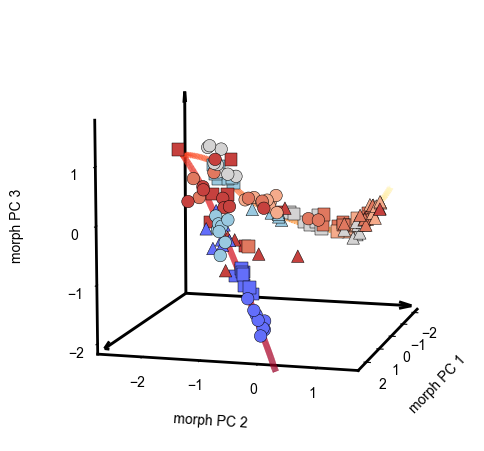

In [16]:
from tqdm import tqdm
z_rotation = 360 + 15
elevation = 10

hf_pca_df["marker_size"] = (hf_pca_df["timepoint"] - 24) / 6 * 1.5 + 3
pca_cols = [col for col in ref_pca_df.columns if "PCA" in col]

temps_to_plot = np.asarray([28.5, 19, 25, 32, 33.5, 35])
times_to_plot = np.asarray([24, 30, 36])
marker_size = 4.5

last_fig = None
for t in tqdm(range(len(times_to_plot)+2)):
    if t == 0:
        opacity = 0
        temp_filter = hf_pca_df["timepoint"] > 0
    elif t < len(times_to_plot) + 1:
        opacity = 1
        tp = np.asarray(times_to_plot[t-1])
        temp_filter = hf_pca_df["timepoint"] == tp
    else:
        opacity = 1
        temp_filter = hf_pca_df["timepoint"] > 0

    fig, ax = create_3d_figure()
    if opacity > 0:
        scatter3d_by_collection(
            ax,
            hf_pca_df.loc[temp_filter],
            x="PCA_00_bio", y="PCA_01_bio", z="PCA_02_bio",
            c="temperature", cmap=TEMP_CMAP, norm=TEMP_NORM,
            marker_size=marker_size, alpha=opacity, edgecolor="black", linewidth=0.35,
        )
    add_gradient_line3d(
        ax,
        spline_df_plot[pca_cols[0]].to_numpy(),
        spline_df_plot[pca_cols[1]].to_numpy(),
        spline_df_plot[pca_cols[2]].to_numpy(),
        spline_df_plot["mdl_stage_hpf"].to_numpy(),
        cmap=SPLINE_CMAP,
        norm=SPLINE_NORM,
        linewidth=4.5,
    )
    style_3d_axes(
        ax,
        axis_labels=pca_axis_labels,
        ranges=(xrange, yrange, zrange),
        elev=elevation,
        azim=z_rotation,
    )
    save_matplotlib_figure(fig, f"hotfish_pca_time{t:02}_v2")
    if last_fig is not None:
        plt.close(last_fig)
    last_fig = fig

plt.show()

### Make rotating plot

In [17]:
start_z_rotation = 72
stop_z_rotation = 360 + 15
start_elevation = -10
stop_elevation = 10
a_vec = np.linspace(start_z_rotation, stop_z_rotation, 50)
e_vec = np.linspace(start_elevation, stop_elevation, 50)

100%|██████████| 50/50 [00:09<00:00,  5.51it/s]


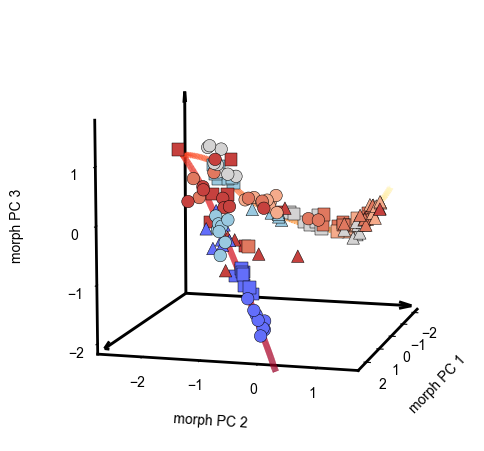

In [18]:
temp_frame_path = os.path.join(fig_path, "temp_pca_rot_frames", "")
os.makedirs(temp_frame_path, exist_ok=True)
marker_size = 4.5
temp_rot_filter = hf_pca_df["timepoint"] > 0
last_fig = None

for i in tqdm(range(len(e_vec))):
    elevation = e_vec[i]
    z_rotation = a_vec[i]

    fig, ax = create_3d_figure()
    scatter3d_by_collection(
        ax,
        hf_pca_df.loc[temp_rot_filter],
        x="PCA_00_bio", y="PCA_01_bio", z="PCA_02_bio",
        c="temperature", cmap=TEMP_CMAP, norm=TEMP_NORM,
        marker_size=marker_size, alpha=1, edgecolor="black", linewidth=0.35,
    )
    add_gradient_line3d(
        ax,
        spline_df_plot[pca_cols[0]].to_numpy(),
        spline_df_plot[pca_cols[1]].to_numpy(),
        spline_df_plot[pca_cols[2]].to_numpy(),
        spline_df_plot["mdl_stage_hpf"].to_numpy(),
        cmap=SPLINE_CMAP,
        norm=SPLINE_NORM,
        linewidth=4.5,
    )
    style_3d_axes(
        ax,
        axis_labels=pca_axis_labels,
        ranges=(xrange, yrange, zrange),
        elev=elevation,
        azim=z_rotation,
    )
    save_matplotlib_figure(fig, f"temp_pca_rot_frames/hotfish_pca_temp{i:02}", png_only=True)
    if last_fig is not None:
        plt.close(last_fig)
    last_fig = fig

plt.show()

In [19]:
hf_pca_df_spline = pd.read_csv(os.path.join(read_path, "hf_pca_morph_df_hooke.csv"))
hf_pca_df_spline.head()

,snip_id,sample,PCA_00_bio,PCA_01_bio,PCA_02_bio,PCA_03_bio,PCA_04_bio,PCA_05_bio,PCA_06_bio,PCA_07_bio,PCA_08_bio,PCA_09_bio,embryo_id,temperature,predicted_stage_hpf,timepoint,mdl_stage_hpf,nn_stage_hpf,morph_dist_spline,morph_branch_flag
0,20240813_24hpf_A02_e00_t0000,hotfish2_P05_A1,2.202903,-0.106507,-1.528073,-0.098564,0.553669,0.022411,0.131667,0.075612,-0.018425,-0.018961,20240813_24hpf_A02_e00,19.0,24.000000,24,14.150698,14.490473,0.449615,False
1,20240813_24hpf_A03_e00_t0000,hotfish2_P05_A2,2.452102,-0.684706,-0.416421,0.273065,-0.588549,-0.098505,-0.182614,-0.038605,-0.025929,-0.011060,20240813_24hpf_A03_e00,25.0,24.002791,24,16.678449,17.768315,0.579035,False
2,20240813_24hpf_A04_e00_t0000,hotfish2_P05_A3,-1.359141,-1.638154,0.326987,0.048033,0.520589,-0.043003,0.022302,-0.058721,-0.087829,0.041582,20240813_24hpf_A04_e00,28.5,24.005593,24,24.137157,25.925120,0.232631,False
3,20240813_24hpf_A05_e00_t0000,hotfish2_P05_A4,-1.757459,-0.959891,-0.306296,-0.114145,0.097003,-0.134306,-0.027518,-0.136830,-0.073319,0.035203,20240813_24hpf_A05_e00,32.0,24.008350,24,28.506869,29.388246,0.254436,False
4,20240813_24hpf_A06_e00_t0000,hotfish2_P05_A5,-1.392493,-1.909045,0.341459,0.341042,0.271710,0.109809,0.082662,-0.025948,-0.104768,0.014036,20240813_24hpf_A06_e00,33.5,24.011122,24,24.187232,25.039300,0.392497,False


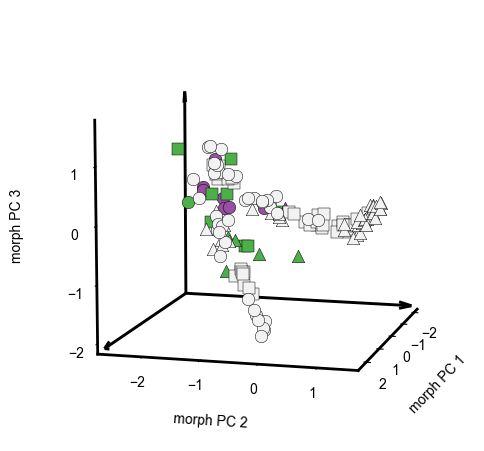

In [20]:
pastel1_last = "#f2f2f2"
set1_purple = "#984ea3"
set1_green = "#4daf4a"
branch_color_map = {"NA": pastel1_last, "main": set1_purple, "branch": set1_green}

hf_pca_df_spline["branch_plot"] = "NA"
hf_pca_df_spline.loc[hf_pca_df_spline["temperature"]>=34, "branch_plot"] = "main"
hf_pca_df_spline.loc[hf_pca_df_spline["morph_branch_flag"]==True, "branch_plot"] = "branch"

fig, ax = create_3d_figure()
branch_filter = hf_pca_df_spline["timepoint"] > 0
for branch_name, branch_color in branch_color_map.items():
    branch_data = hf_pca_df_spline.loc[branch_filter & (hf_pca_df_spline["branch_plot"] == branch_name)]
    if branch_data.empty:
        continue
    for timepoint in collection_values(branch_data):
        plot_data = branch_data.loc[np.isclose(branch_data["timepoint"].astype(float), float(timepoint))]
        if plot_data.empty:
            continue
        ax.scatter(
            plot_data["PCA_00_bio"], plot_data["PCA_01_bio"], plot_data["PCA_02_bio"],
            color=branch_color, marker=marker_for_collection(timepoint),
            s=point_area(marker_size), alpha=1,
            edgecolors="black", linewidths=0.35, depthshade=False,
        )

style_3d_axes(
    ax,
    axis_labels=pca_axis_labels,
    ranges=(xrange, yrange, zrange),
    elev=stop_elevation,
    azim=stop_z_rotation,
)
save_matplotlib_figure(fig, "hotfish_pca_hooke_branch")
plt.show()

### Make volcano plot of Hooke contrast results

In [21]:
contrast_candidates = [
    "/Users/nick/Cole Trapnell's Lab Dropbox/Nick Lammers/Nick/morphseq/analyses/crossmodal/hotfish/hotfish_morph_ccs_contrast.csv",
    "/Users/nick/Cole Trapnell's Lab Dropbox/Nick Lammers/Nick/morphseq/analysis/crossmodal/hotfish/hotfish_morph_ccs_contrast.csv",
    "/Users/nick/Projects/data/morphseq/results/20260528/hotfish_morph_ccs_contrast.csv",
]
contrast_path = next(path for path in contrast_candidates if os.path.exists(path))
contrast_df = pd.read_csv(contrast_path)
contrast_df["delta_log_abund"] = -contrast_df["delta_log_abund"]
contrast_df["delta_abund"] = np.exp(contrast_df["delta_log_abund"])
# contrast_df["log_q"] = np.log(contrast_df["delta_q_value"])
contrast_df["sig_flag"] = contrast_df["delta_q_value"] >= 0.05
contrast_df.head()

,cell_group,delta_log_abund,delta_log_abund_se,delta_q_value,delta_abund,sig_flag
0,adenohypophysis,0.889436,0.703418,0.696196,2.433756,True
1,adrenal gland,0.290252,0.527964,0.873351,1.336764,True
2,"apical ectodermal ridge, median or pectoral",0.005277,0.208720,0.998161,1.005291,True
3,"basal cell, early",0.361935,0.269239,0.672163,1.436105,True
4,cardiomyocyte,-0.215626,0.233134,0.807322,0.806036,True


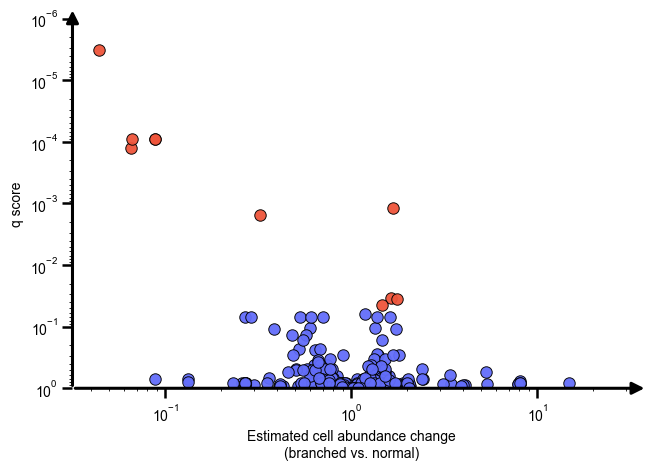

In [22]:
fig, ax = plt.subplots(figsize=(7.2, 4.8), facecolor="white")

sig_colors = {True: "#636EFA", False: "#EF553B"}
for sig_flag, plot_data in contrast_df.groupby("sig_flag", sort=False):
    ax.scatter(
        plot_data["delta_abund"],
        plot_data["delta_q_value"],
        s=68,
        color=sig_colors[bool(sig_flag)],
        edgecolor="black",
        linewidth=0.7,
        alpha=0.95,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10**-1.5, 10**1.5)
ax.set_ylim(1, 10**-6)
ax.set_xlabel("Estimated cell abundance change\n(branched vs. normal)")
ax.set_ylabel("q score")
ax.grid(False)
set_axis_arrows_2d(ax)
save_matplotlib_figure(fig, "hooke_branch_contrast")
plt.show()

In [23]:
1e1

10.0